In [44]:
import numpy as np
import seaborn as sns
from statsmodels import imputation as imp
import matplotlib.pyplot as plt
import pandas as pd
import os

In [45]:

data = pd.read_csv('data/stop_times.txt')

print(data.columns)

Index(['trip_id', 'stop_id', 'stop_sequence', 'shape_dist_traveled',
       'arrival_time', 'departure_time'],
      dtype='str')


In [46]:
def fix_time(t):
    if pd.isna(t):
        return t

    h, m, s = map(int, str(t).split(":"))
    h = h % 24

    return f"{h:02d}:{m:02d}:{s:02d}"


# fix invalid hours like 24:xx:xx or 25:xx:xx
data["arrival_time"] = data["arrival_time"].apply(fix_time)
data["departure_time"] = data["departure_time"].apply(fix_time)

# convert to datetime
data["arrival_time"] = pd.to_datetime(
    data["arrival_time"],
    format="%H:%M:%S"
)

data["departure_time"] = pd.to_datetime(
    data["departure_time"],
    format="%H:%M:%S"
)

<Axes: xlabel='hour'>

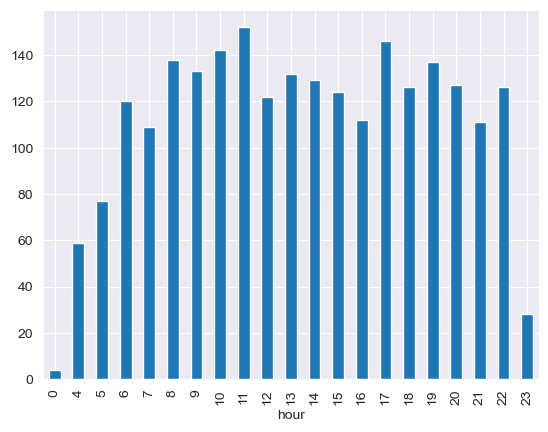

In [47]:
data.describe()
data.apply(np.max)
data["hour"] = data["departure_time"].dt.hour

data["hour"].value_counts().sort_index().plot(kind="bar")

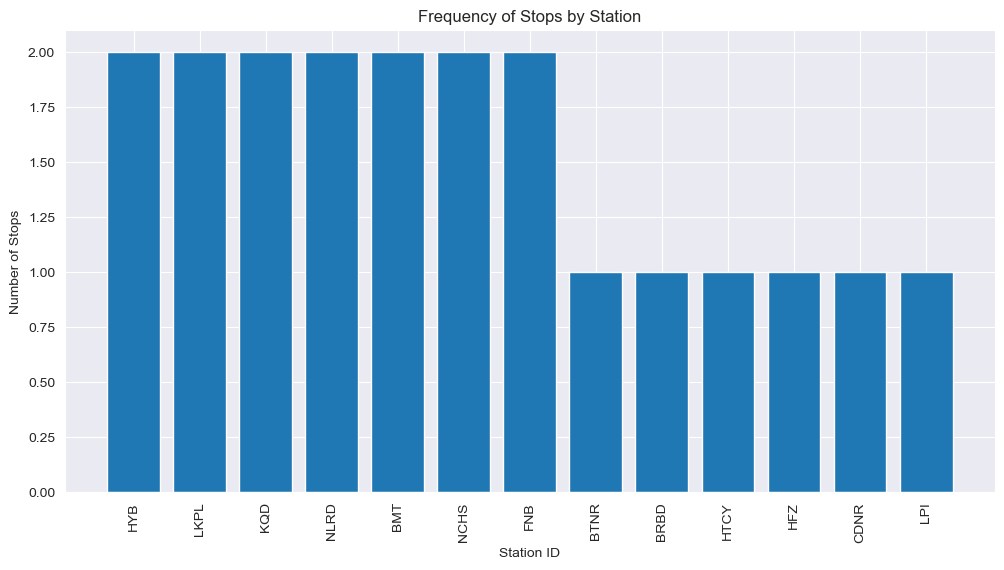

In [48]:
counts = data["stop_id"].head(20).value_counts()

plt.figure(figsize=(12, 6))
plt.bar(counts.index, counts.values)

plt.xlabel("Station ID")
plt.ylabel("Number of Stops")
plt.title("Frequency of Stops by Station")

plt.xticks(rotation=90)

plt.show()

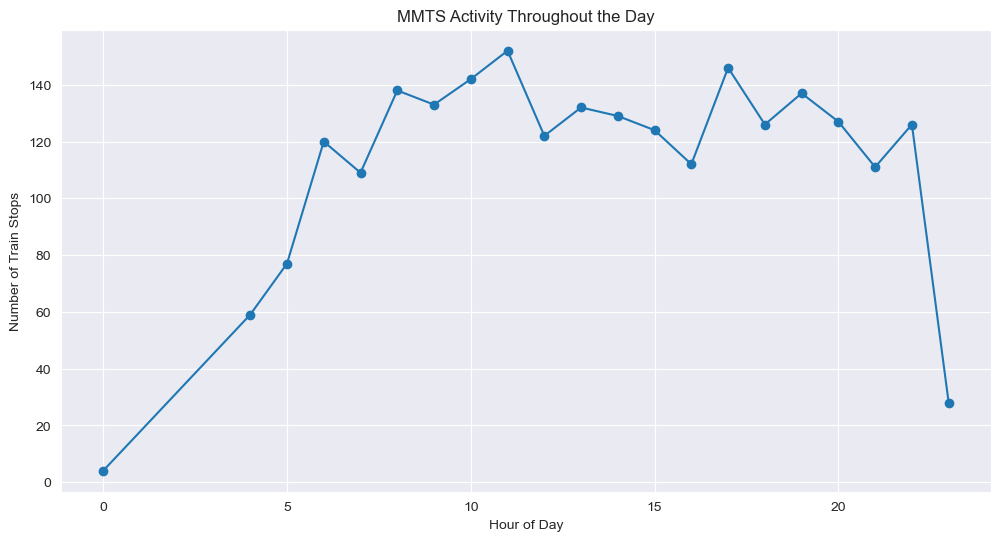

In [49]:
data["travel_segment"] = (
        data.groupby("trip_id")["arrival_time"]
        .diff()
        .dt.total_seconds() / 60
)
hour_counts = data["hour"].value_counts().sort_index()

plt.figure(figsize=(12, 6))
plt.plot(hour_counts.index, hour_counts.values, marker='o')

plt.xlabel("Hour of Day")
plt.ylabel("Number of Train Stops")
plt.title("MMTS Activity Throughout the Day")

plt.grid(True)

plt.show()

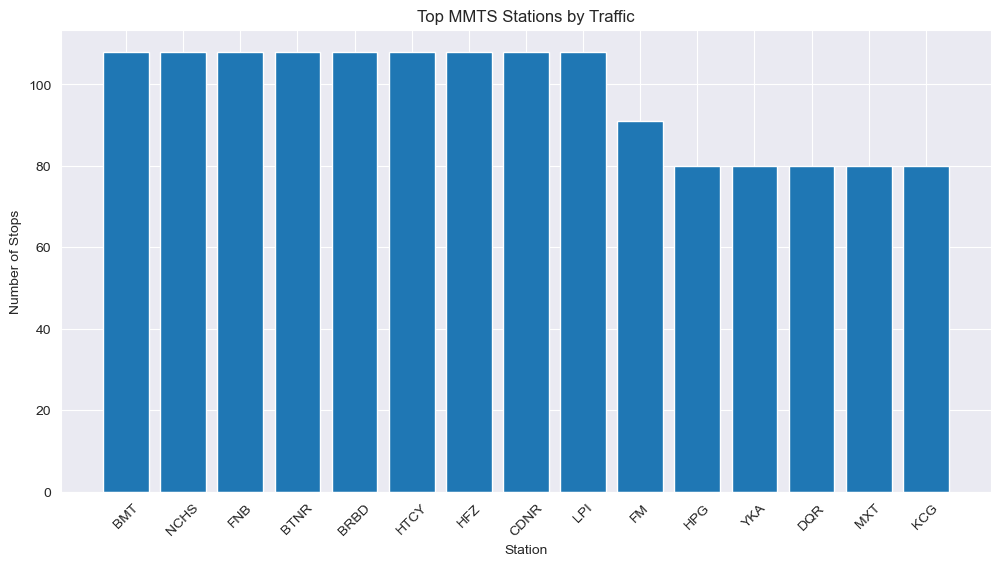

count    57.000000
mean     19.561404
std      11.061545
min       0.000000
25%      10.000000
50%      19.000000
75%      30.000000
max      45.000000
Name: gap_minutes, dtype: float64


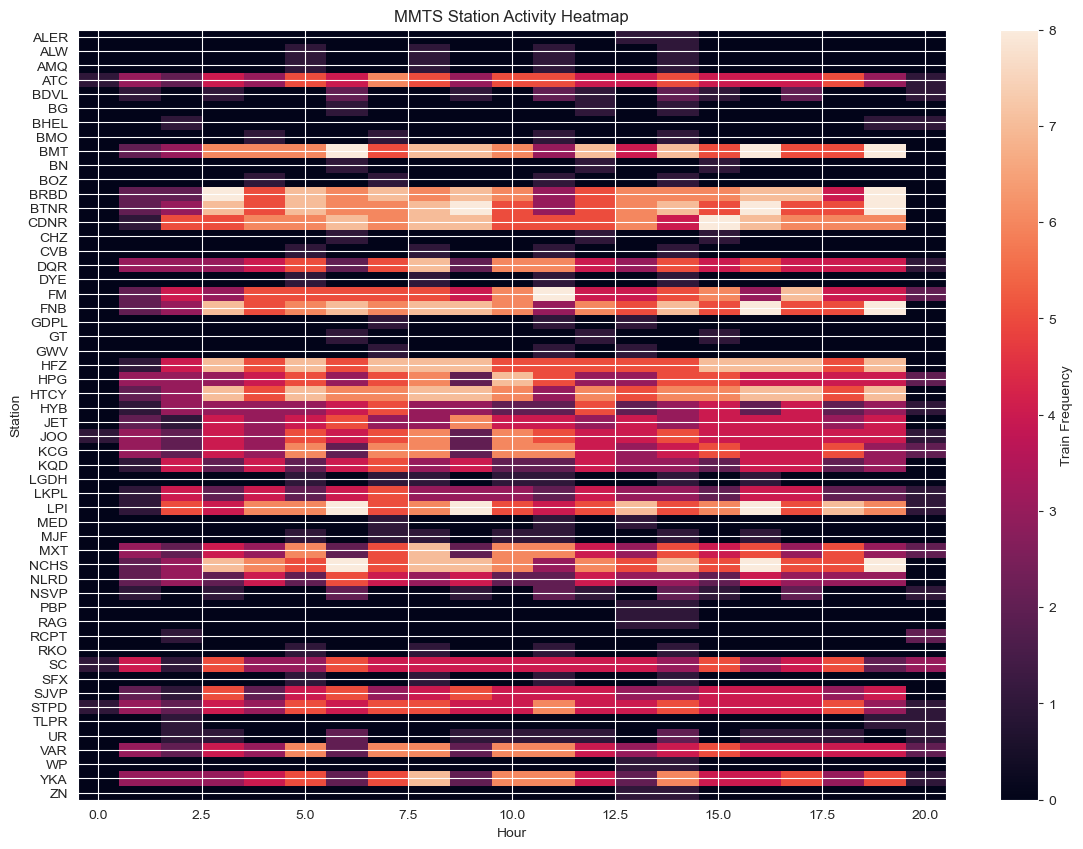

In [50]:
top_stations = data["stop_id"].value_counts().head(15)

plt.figure(figsize=(12, 6))
plt.bar(top_stations.index, top_stations.values)

plt.xticks(rotation=45)

plt.xlabel("Station")
plt.ylabel("Number of Stops")
plt.title("Top MMTS Stations by Traffic")

plt.show()
station_data = data[data["stop_id"] == "HYB"].copy()

station_data = station_data.sort_values("arrival_time")

station_data["gap_minutes"] = (
        station_data["arrival_time"]
        .diff()
        .dt.total_seconds() / 60
)

print(station_data["gap_minutes"].describe())

trips = pd.read_csv("data/trips.txt")

merged = pd.merge(
    data,
    trips,
    on="trip_id",
    how="left"
)
pivot = pd.crosstab(
    data["stop_id"],
    data["hour"]
)

plt.figure(figsize=(14, 10))

plt.imshow(pivot, aspect='auto')

plt.colorbar(label="Train Frequency")

plt.yticks(range(len(pivot.index)), pivot.index)

plt.xlabel("Hour")
plt.ylabel("Station")
plt.title("MMTS Station Activity Heatmap")

plt.show()


In [51]:

delay_data = pd.read_csv(
    "data/etrain_delays.csv"
)

print(delay_data.head())

print(delay_data.info())



   train_number      train_name station_code     station_name  \
0         12673  Cheran Express          MAS  CHENNAI CENTRAL   
1         12673  Cheran Express          AVD            AVADI   
2         12673  Cheran Express          AJJ        ARAKKONAM   
3         12673  Cheran Express          KPD       KATPADI JN   
4         12673  Cheran Express          JTJ      JOLARPETTAI   

   average_delay_minutes  pct_right_time  pct_slight_delay  \
0                    2.0           98.90              0.27   
1                    0.0            0.27              0.00   
2                   16.0           55.34             44.38   
3                   17.0           48.49             49.86   
4                    NaN           70.96             27.67   

   pct_significant_delay  pct_cancelled_unknown  \
0                   0.00                   0.83   
1                   0.00                  99.73   
2                   0.27                   0.01   
3                   1.64        

In [52]:

print(
    delay_data.isnull().sum()
)



train_number               0
train_name                 0
station_code               0
station_name               0
average_delay_minutes    236
pct_right_time             0
pct_slight_delay           0
pct_significant_delay      0
pct_cancelled_unknown      0
scraped_at                 0
source_url                 0
dtype: int64


In [53]:
delay_data["average_delay_minutes"] = ( delay_data["average_delay_minutes"] .fillna( delay_data["average_delay_minutes"].median() ) )

In [54]:
numeric_cols = [ "average_delay_minutes",
                 "pct_right_time",
                 "pct_slight_delay",
                 "pct_significant_delay",
                 "pct_cancelled_unknown" ]
delay_data[numeric_cols] = ( delay_data[numeric_cols] .apply(pd.to_numeric, errors="coerce") )

In [55]:
delay_data = delay_data.dropna()

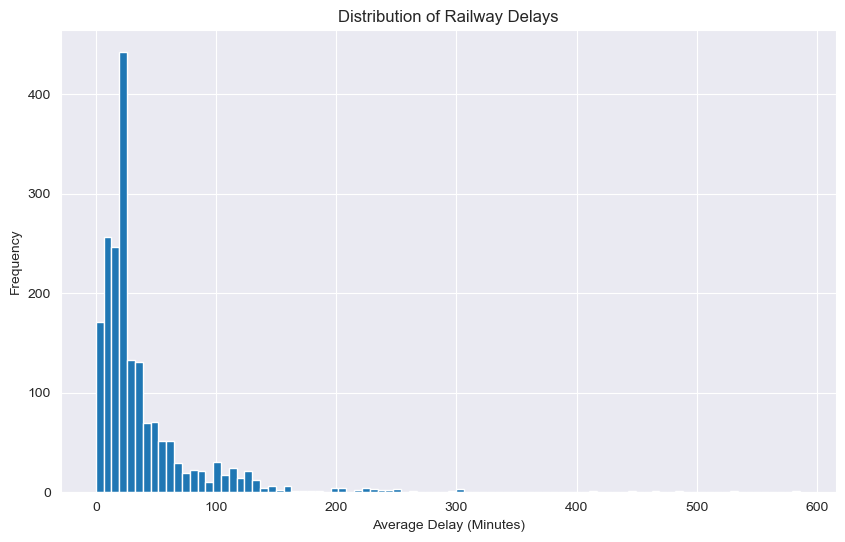

In [56]:

plt.figure(figsize=(10,6))

plt.hist(
    delay_data["average_delay_minutes"],
    bins=90
)

plt.xlabel("Average Delay (Minutes)")
plt.ylabel("Frequency")

plt.title("Distribution of Railway Delays")

plt.show()



In [57]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
#after the eda, we notice the important parts of our dataset
features = [
    "pct_right_time",
    "pct_slight_delay",
    "pct_significant_delay",
    "pct_cancelled_unknown"
]

X = delay_data[features]

y = delay_data["average_delay_minutes"]

# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# We choose the parameters of the random forest to suit the size of the dataset.
rf_regressor = RandomForestRegressor(
    n_estimators=150,
    max_depth=70,
    random_state=42
)

# Training the random forest model

rf_regressor.fit(X_train, y_train)

# Prediction
predictions = rf_regressor.predict(X_test)

# EVALUATION

mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

print("\nModel Performance:\n")

print(f"MAE  : {mae:.2f} minutes")
print(f"RMSE : {rmse:.2f} minutes")
print(f"R²   : {r2:.4f}")


Model Performance:

MAE  : 10.85 minutes
RMSE : 25.99 minutes
R²   : 0.4147


In [58]:
#Feature importance

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf_regressor.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance:\n")
print(importance_df)



Feature Importance:

                 Feature  Importance
2  pct_significant_delay    0.667872
1       pct_slight_delay    0.184689
3  pct_cancelled_unknown    0.085617
0         pct_right_time    0.061822


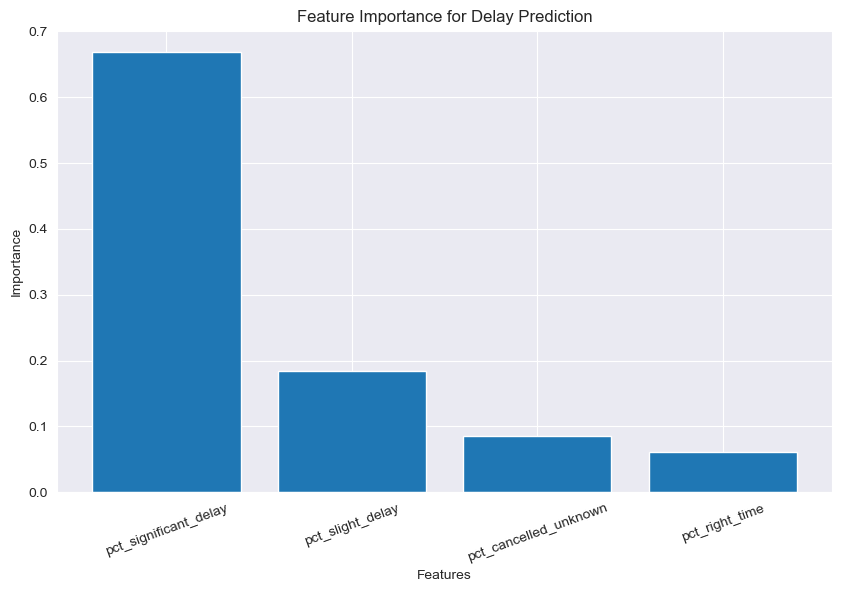

In [59]:
#plotting of the features
plt.figure(figsize=(10, 6))

plt.bar(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Features")
plt.ylabel("Importance")

plt.title("Feature Importance for Delay Prediction")

plt.xticks(rotation=20)

plt.show()

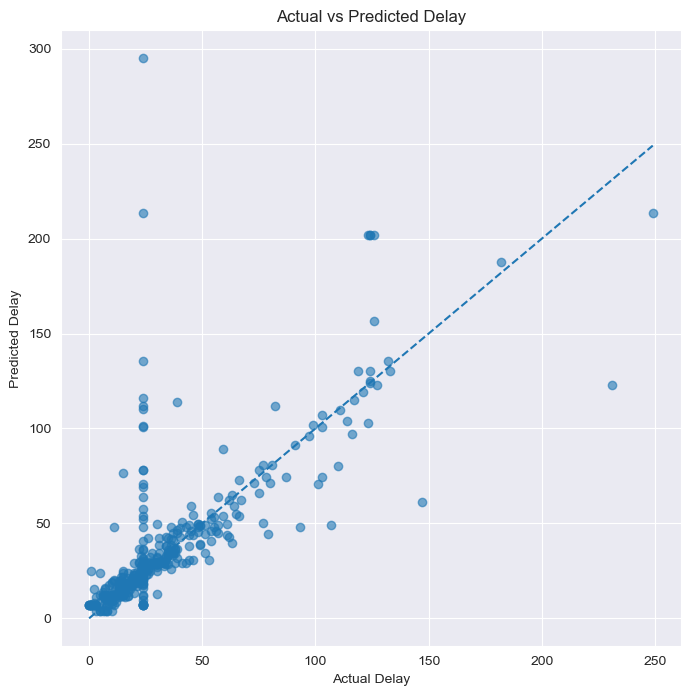

In [60]:
#plotting the predictions
plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    predictions,
    alpha=0.6
)

plt.xlabel("Actual Delay")
plt.ylabel("Predicted Delay")

plt.title("Actual vs Predicted Delay")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()


In [61]:
#saving the model
import joblib

joblib.dump(
    rf_regressor,
    "models/delay_predictor.pkl"
)

print("\nModel saved successfully.")


Model saved successfully.
